# Trial-Averaged XSENS vs Vicon Agreement

This notebook compares XSENS-derived features against rebuilt Vicon marker annotations after averaging repeated trials.

- Keeps only SRS stroke participants.
- Uses `Vicon - Annotations_long.csv`, rebuilt from raw Vicon CSV trials.
- Uses trial-level XSENS results from `XSENS_results/`.
- Averages repeated trials within each `subject_id + visit_id + activity` for both Vicon and XSENS.
- Matches averaged rows by `subject_id`, `visit_id`, and `activity`.
- Shows visit-level errors, scatter plots, and Bland-Altman plots.


In [1]:
from pathlib import Path
import sys
import pandas as pd

cwd = Path.cwd()
if (cwd / "agreement_plots.py").exists():
    sys.path.insert(0, str(cwd))
elif (cwd / "Sensors_Visualizers" / "agreement_plots.py").exists():
    sys.path.insert(0, str(cwd / "Sensors_Visualizers"))

from agreement_plots import SPECS, all_metric_summary, display_feature_report, participant_agreement_table

pd.set_option("display.max_columns", 50)
pd.set_option("display.precision", 3)
pd.set_option("display.float_format", lambda value: f"{value:.3f}")

spec_by_title = {spec.title: spec for spec in SPECS}
print("Setup complete")

Setup complete


## Metric Summary

Use this table to decide which features are strongest before showing the plots.

In [2]:
summary = all_metric_summary()
display(summary.sort_values(["activity", "feature"]))

,activity,feature,xsens_column,vicon_column,unit,n,mae,rmse,bias,pearson_r,icc_2_1
3,left_turn,Left Turn Duration,sacrum_duration_s,duration_s,s,12,0.677,0.852,0.397,0.971,0.946
4,left_turn,Left Turn Step Count,sacrum_step_count,step_count,steps,12,1.250,1.756,-0.917,0.904,0.798
5,right_turn,Right Turn Duration,sacrum_duration_s,duration_s,s,14,1.166,1.763,-0.646,0.890,0.883
6,right_turn,Right Turn Step Count,sacrum_step_count,step_count,steps,14,2.286,2.478,-0.857,0.867,0.803
7,sit_to_stand,Sit-to-Stand Duration,sacrum_duration_s,duration_s,s,15,0.589,0.735,-0.289,0.642,0.549
1,walk,Walking 10-Step Cadence,sacrum_cadence_steps_min,cadence_steps_min,steps/min,16,10.817,13.963,-0.252,0.754,0.765
0,walk,Walking 10-Step Duration,sacrum_duration_s,duration_s,s,16,0.928,1.188,-0.006,0.772,0.781
2,walk,Walking 10-Step Mean Step Time,sacrum_mean_step_time_s,mean_step_time_s,s,16,0.093,0.119,-0.001,0.773,0.781


## Walking 10-Step Duration

,n,mae,rmse,bias,pearson_r,icc_2_1
0,16,0.928,1.188,-0.006,0.772,0.781


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,walk,5.440,4.830,4.830,-0.610,0.610,11.213
1,SRS02,V01,walk,5.190,6.610,6.610,1.420,1.420,27.360
2,SRS03,V01,walk,6.800,7.300,7.300,0.500,0.500,7.353
3,SRS04,V01,walk,8.330,8.730,8.730,0.400,0.400,4.802
4,SRS05,V01,walk,6.070,6.190,6.190,0.120,0.120,1.977
5,SRS07,V01,walk,9.525,10.410,10.410,0.885,0.885,9.291
6,SRS08,V01,walk,5.445,5.620,5.620,0.175,0.175,3.214
7,SRS09,V01,walk,5.685,5.590,5.590,-0.095,0.095,1.671
8,SRS10,V01,walk,6.515,5.110,5.110,-1.405,1.405,21.566
9,SRS12,V01,walk,9.615,9.240,9.240,-0.375,0.375,3.900


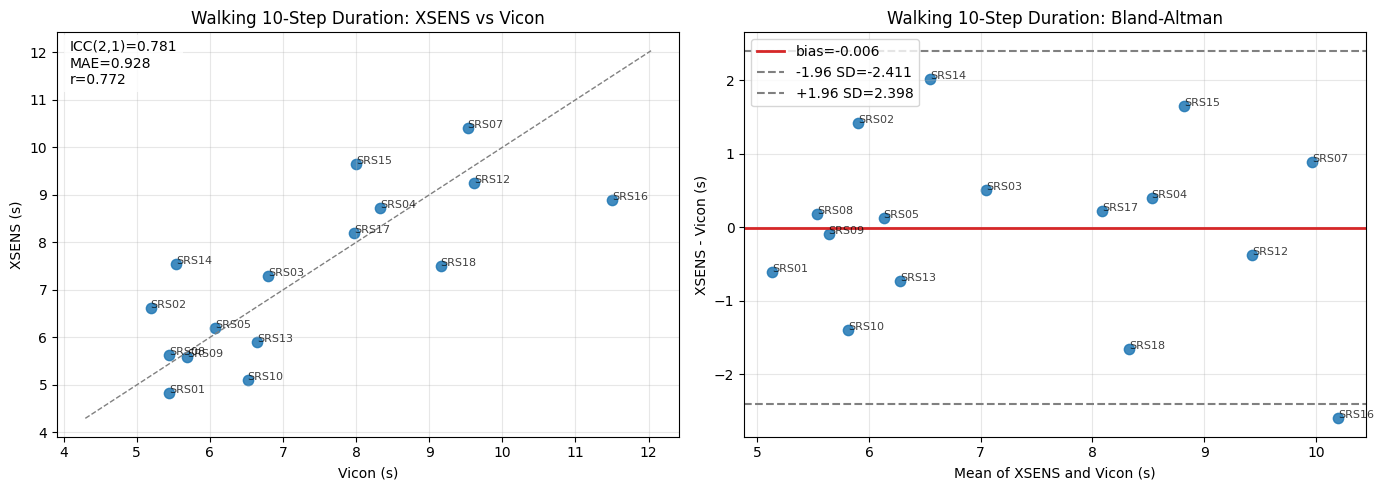

In [3]:
display_feature_report(spec_by_title["Walking 10-Step Duration"])

## Walking 10-Step Cadence

,n,mae,rmse,bias,pearson_r,icc_2_1
0,16,10.817,13.963,-0.252,0.754,0.765


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,walk,110.294,124.224,124.224,13.930,13.930,12.630
1,SRS02,V01,walk,115.607,90.772,90.772,-24.835,24.835,21.482
2,SRS03,V01,walk,88.235,82.192,82.192,-6.043,6.043,6.849
3,SRS04,V01,walk,72.029,68.729,68.729,-3.300,3.300,4.581
4,SRS05,V01,walk,98.847,96.931,96.931,-1.916,1.916,1.938
5,SRS07,V01,walk,62.992,57.637,57.637,-5.355,5.355,8.501
6,SRS08,V01,walk,110.193,106.762,106.762,-3.431,3.431,3.114
7,SRS09,V01,walk,105.541,107.335,107.335,1.794,1.794,1.700
8,SRS10,V01,walk,92.095,117.417,117.417,25.322,25.322,27.496
9,SRS12,V01,walk,62.402,64.935,64.935,2.533,2.533,4.059


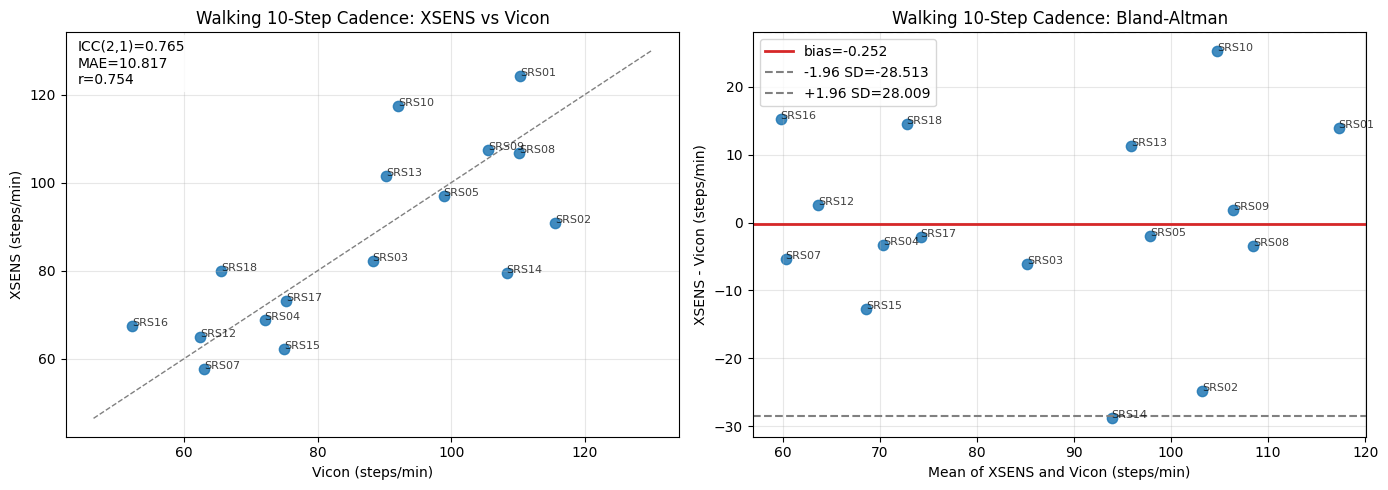

In [4]:
display_feature_report(spec_by_title["Walking 10-Step Cadence"])

## Left Turn Duration

,n,mae,rmse,bias,pearson_r,icc_2_1
0,12,0.677,0.852,0.397,0.971,0.946


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,left_turn,5.500,5.090,5.090,-0.410,0.410,7.455
1,SRS05,V01,left_turn,7.500,6.940,6.940,-0.560,0.560,7.467
2,SRS08,V01,left_turn,5.100,4.800,4.800,-0.300,0.300,5.882
3,SRS09,V01,left_turn,5.000,5.900,5.900,0.900,0.900,18.000
4,SRS10,V01,left_turn,3.900,3.810,3.810,-0.090,0.090,2.308
5,SRS12,V01,left_turn,8.000,8.550,8.550,0.550,0.550,6.875
6,SRS13,V01,left_turn,5.200,4.950,4.950,-0.250,0.250,4.808
7,SRS14,V01,left_turn,9.800,10.730,10.730,0.930,0.930,9.490
8,SRS15,V01,left_turn,9.800,9.730,9.730,-0.070,0.070,0.714
9,SRS16,V01,left_turn,6.500,7.230,7.230,0.730,0.730,11.231


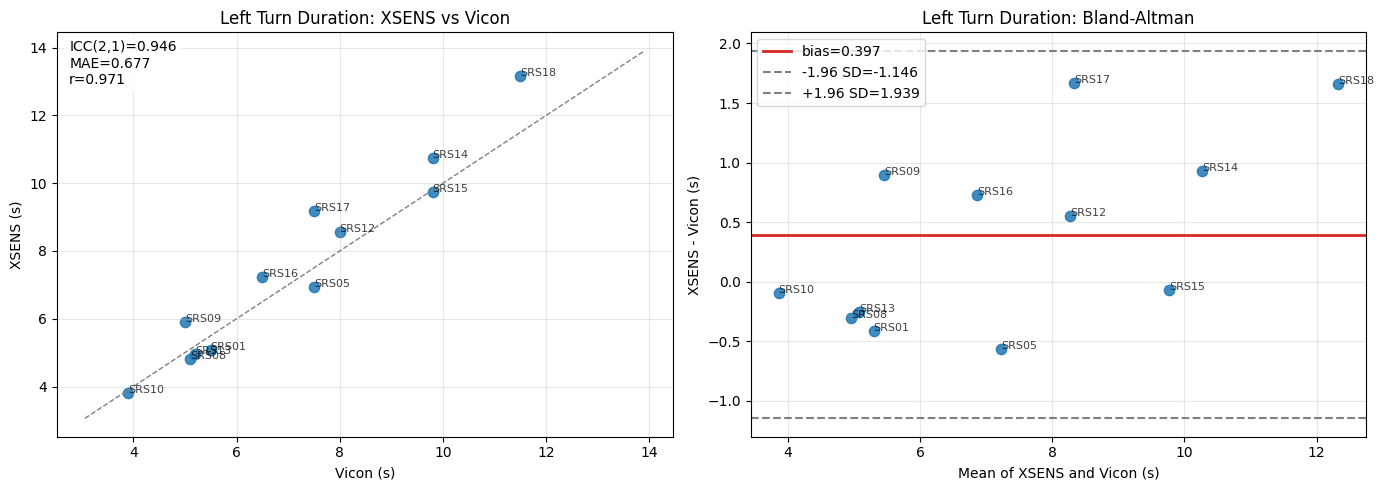

In [5]:
display_feature_report(spec_by_title["Left Turn Duration"])

## Left Turn Step Count

,n,mae,rmse,bias,pearson_r,icc_2_1
0,12,1.250,1.756,-0.917,0.904,0.798


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,left_turn,9.000,8.000,8.000,-1.000,1.000,11.111
1,SRS05,V01,left_turn,9.000,9.000,9.000,0.000,0.000,0.000
2,SRS08,V01,left_turn,8.000,5.000,5.000,-3.000,3.000,37.500
3,SRS09,V01,left_turn,8.000,7.000,7.000,-1.000,1.000,12.500
4,SRS10,V01,left_turn,8.000,4.000,4.000,-4.000,4.000,50.000
5,SRS12,V01,left_turn,9.000,9.000,9.000,0.000,0.000,0.000
6,SRS13,V01,left_turn,9.000,7.000,7.000,-2.000,2.000,22.222
7,SRS14,V01,left_turn,13.000,13.000,13.000,0.000,0.000,0.000
8,SRS15,V01,left_turn,12.000,13.000,13.000,1.000,1.000,8.333
9,SRS16,V01,left_turn,12.000,10.000,10.000,-2.000,2.000,16.667


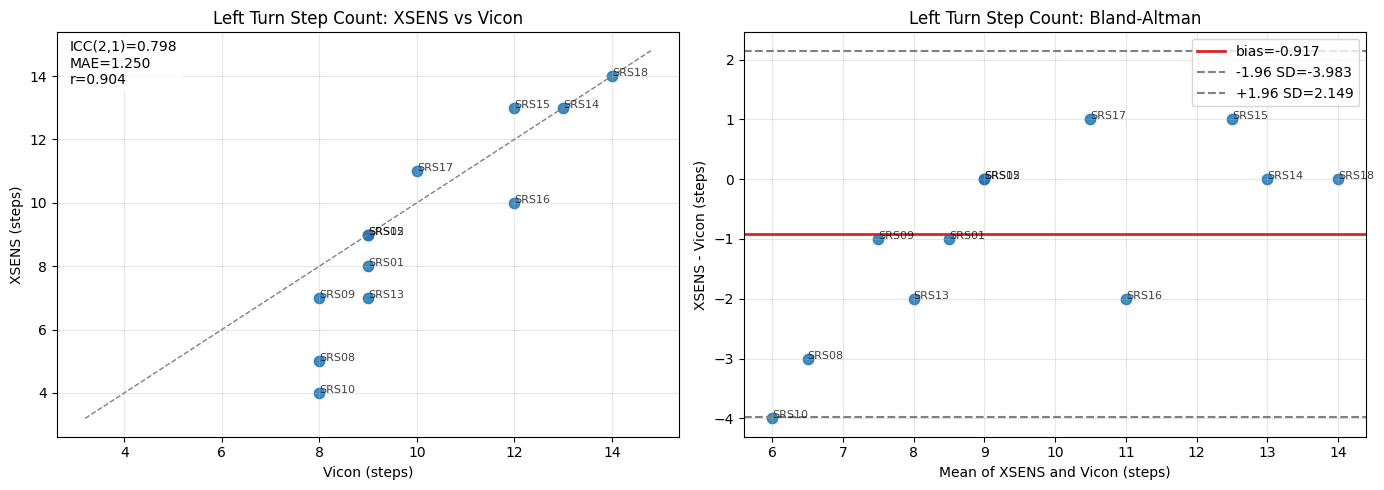

In [6]:
display_feature_report(spec_by_title["Left Turn Step Count"])

## Right Turn Duration

,n,mae,rmse,bias,pearson_r,icc_2_1
0,14,1.166,1.763,-0.646,0.890,0.883


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,right_turn,5.900,5.800,5.800,-0.100,0.100,1.695
1,SRS04,V01,right_turn,11.000,10.070,10.070,-0.930,0.930,8.455
2,SRS05,V01,right_turn,11.000,6.120,6.120,-4.880,4.880,44.364
3,SRS07,V01,right_turn,12.300,9.030,9.030,-3.270,3.270,26.585
4,SRS08,V01,right_turn,5.400,5.960,5.960,0.560,0.560,10.370
5,SRS09,V01,right_turn,4.700,3.970,3.970,-0.730,0.730,15.532
6,SRS10,V01,right_turn,4.500,5.110,5.110,0.610,0.610,13.556
7,SRS12,V01,right_turn,9.900,10.400,10.400,0.500,0.500,5.051
8,SRS13,V01,right_turn,4.100,3.660,3.660,-0.440,0.440,10.732
9,SRS14,V01,right_turn,13.100,13.710,13.710,0.610,0.610,4.656


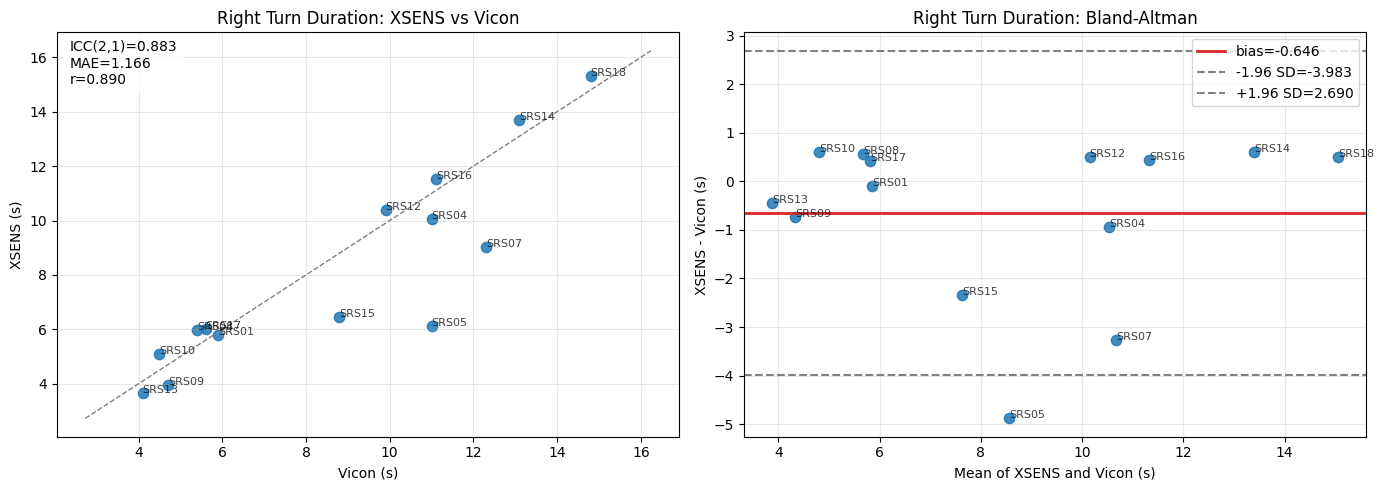

In [7]:
display_feature_report(spec_by_title["Right Turn Duration"])

## Right Turn Step Count

,n,mae,rmse,bias,pearson_r,icc_2_1
0,14,2.286,2.478,-0.857,0.867,0.803


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,right_turn,10.000,8.000,8.000,-2.000,2.000,20.000
1,SRS04,V01,right_turn,9.000,11.000,11.000,2.000,2.000,22.222
2,SRS05,V01,right_turn,10.000,7.000,7.000,-3.000,3.000,30.000
3,SRS07,V01,right_turn,13.000,11.000,11.000,-2.000,2.000,15.385
4,SRS08,V01,right_turn,6.000,7.000,7.000,1.000,1.000,16.667
5,SRS09,V01,right_turn,8.000,5.000,5.000,-3.000,3.000,37.500
6,SRS10,V01,right_turn,8.000,6.000,6.000,-2.000,2.000,25.000
7,SRS12,V01,right_turn,13.000,11.000,11.000,-2.000,2.000,15.385
8,SRS13,V01,right_turn,6.000,5.000,5.000,-1.000,1.000,16.667
9,SRS14,V01,right_turn,15.000,19.000,19.000,4.000,4.000,26.667


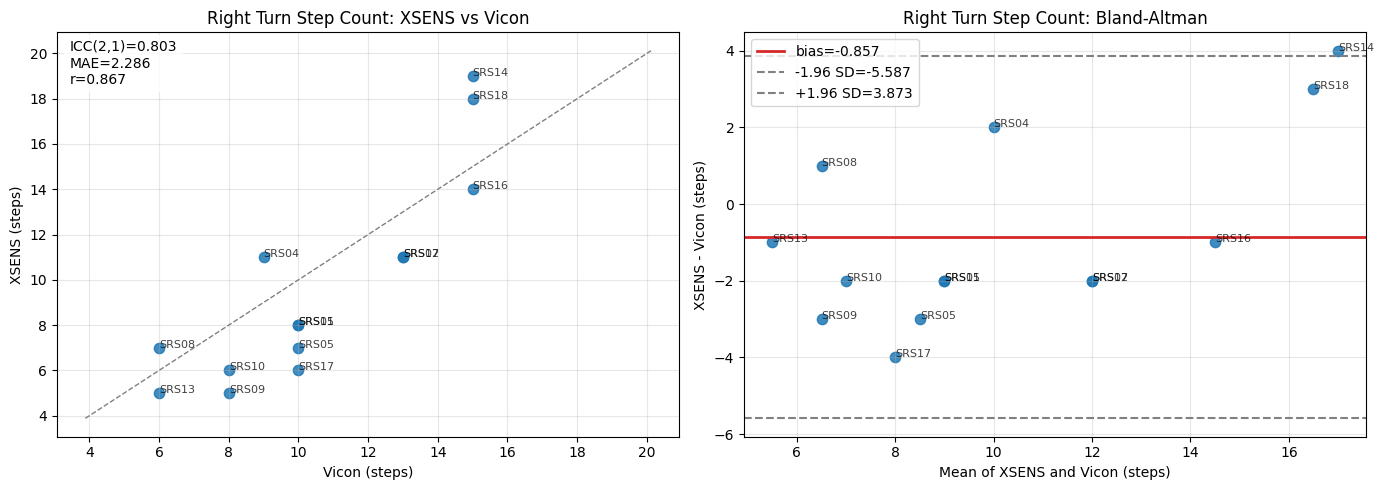

In [8]:
display_feature_report(spec_by_title["Right Turn Step Count"])

## Sit-to-Stand Duration

,n,mae,rmse,bias,pearson_r,icc_2_1
0,15,0.589,0.735,-0.289,0.642,0.549


,subject_id,visit_id,activity,vicon,xsens,xsens_raw,error,abs_error,percent_error
0,SRS01,V01,sit_to_stand,1.000,0.340,0.340,-0.660,0.660,66.000
1,SRS03,V01,sit_to_stand,1.300,0.790,0.790,-0.510,0.510,39.231
2,SRS04,V01,sit_to_stand,2.300,2.740,2.740,0.440,0.440,19.130
3,SRS05,V01,sit_to_stand,2.300,1.630,1.630,-0.670,0.670,29.130
4,SRS07,V01,sit_to_stand,2.200,1.270,1.270,-0.930,0.930,42.273
5,SRS08,V01,sit_to_stand,1.200,0.830,0.830,-0.370,0.370,30.833
6,SRS09,V01,sit_to_stand,1.300,1.370,1.370,0.070,0.070,5.385
7,SRS10,V01,sit_to_stand,2.400,2.060,2.060,-0.340,0.340,14.167
8,SRS12,V01,sit_to_stand,1.200,1.030,1.030,-0.170,0.170,14.167
9,SRS13,V01,sit_to_stand,1.100,1.810,1.810,0.710,0.710,64.545


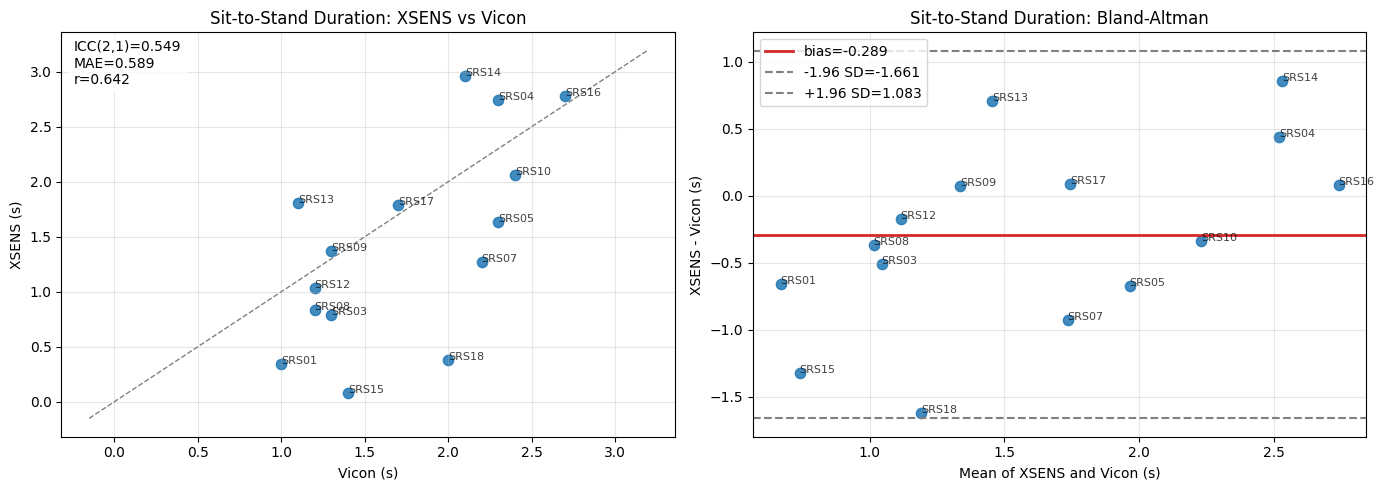

In [9]:
display_feature_report(spec_by_title["Sit-to-Stand Duration"])